## Executive Summary

This analysis builds a predictive model to identify at-risk customers and quantify the business case for retention interventions.

**Key Findings:**
- 26.5% baseline churn rate across 7,043 customers
- Month-to-month contracts churn at 42.7% vs 2.8% for two-year contracts
- New customers (1-4 months tenure) paying premium prices ($81-$100/month) are 94%+ likely to churn
- $2.5M in annual revenue is at risk across all customer segments

**Model Performance:**
- Logistic Regression: 84% AUC, 78% recall on churners (identifies actual churners correctly)
- Model identifies 2,871 at-risk customers requiring targeted retention action

**Business Impact:**
- Retention program ROI: 486% 
- Potential annual revenue saved: $1,474,889
- Net program cost: $251,781
- Action list exported with personalized recommendations for each customer




In [40]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, pointbiserialr, ttest_ind
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [41]:
chn = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [42]:
chn.head(15)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [43]:
chn.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [44]:
chn.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [45]:
chn['MonthlyCharges'].apply(type).value_counts()

MonthlyCharges
<class 'float'>    7043
Name: count, dtype: int64

In [46]:
chn.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [47]:
#Check for hidden characters in cheurn field before converting to bnary
chn['Churn'].apply(lambda x: repr(x)).unique()

<StringArray>
[''No'', ''Yes'']
Length: 2, dtype: str

In [48]:
chn.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [49]:

chn['Churn'] = (
    chn['Churn']
    .astype(str)
    .str.replace("'", "", regex=False)  # remove the single quotes
)

In [50]:
chn['Churn'] = chn['Churn'].map({'Yes': 1, 'No': 0})

In [51]:
chn.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [52]:
chn['TotalCharges'] = (
    pd.to_numeric(chn['TotalCharges'], errors='coerce')  # convert strings → float, bad values → NaN
      .fillna(0.0)                                     # replace NaN with 0
)

In [53]:
#Check if all the customerids are unique to know if there are duplicates
chn['customerID'].nunique(), len(chn)

(7043, 7043)

In [54]:
#Overall Conversion Rate
chn.groupby('customerID')['Churn'].max().mean()

np.float64(0.2653698707936959)

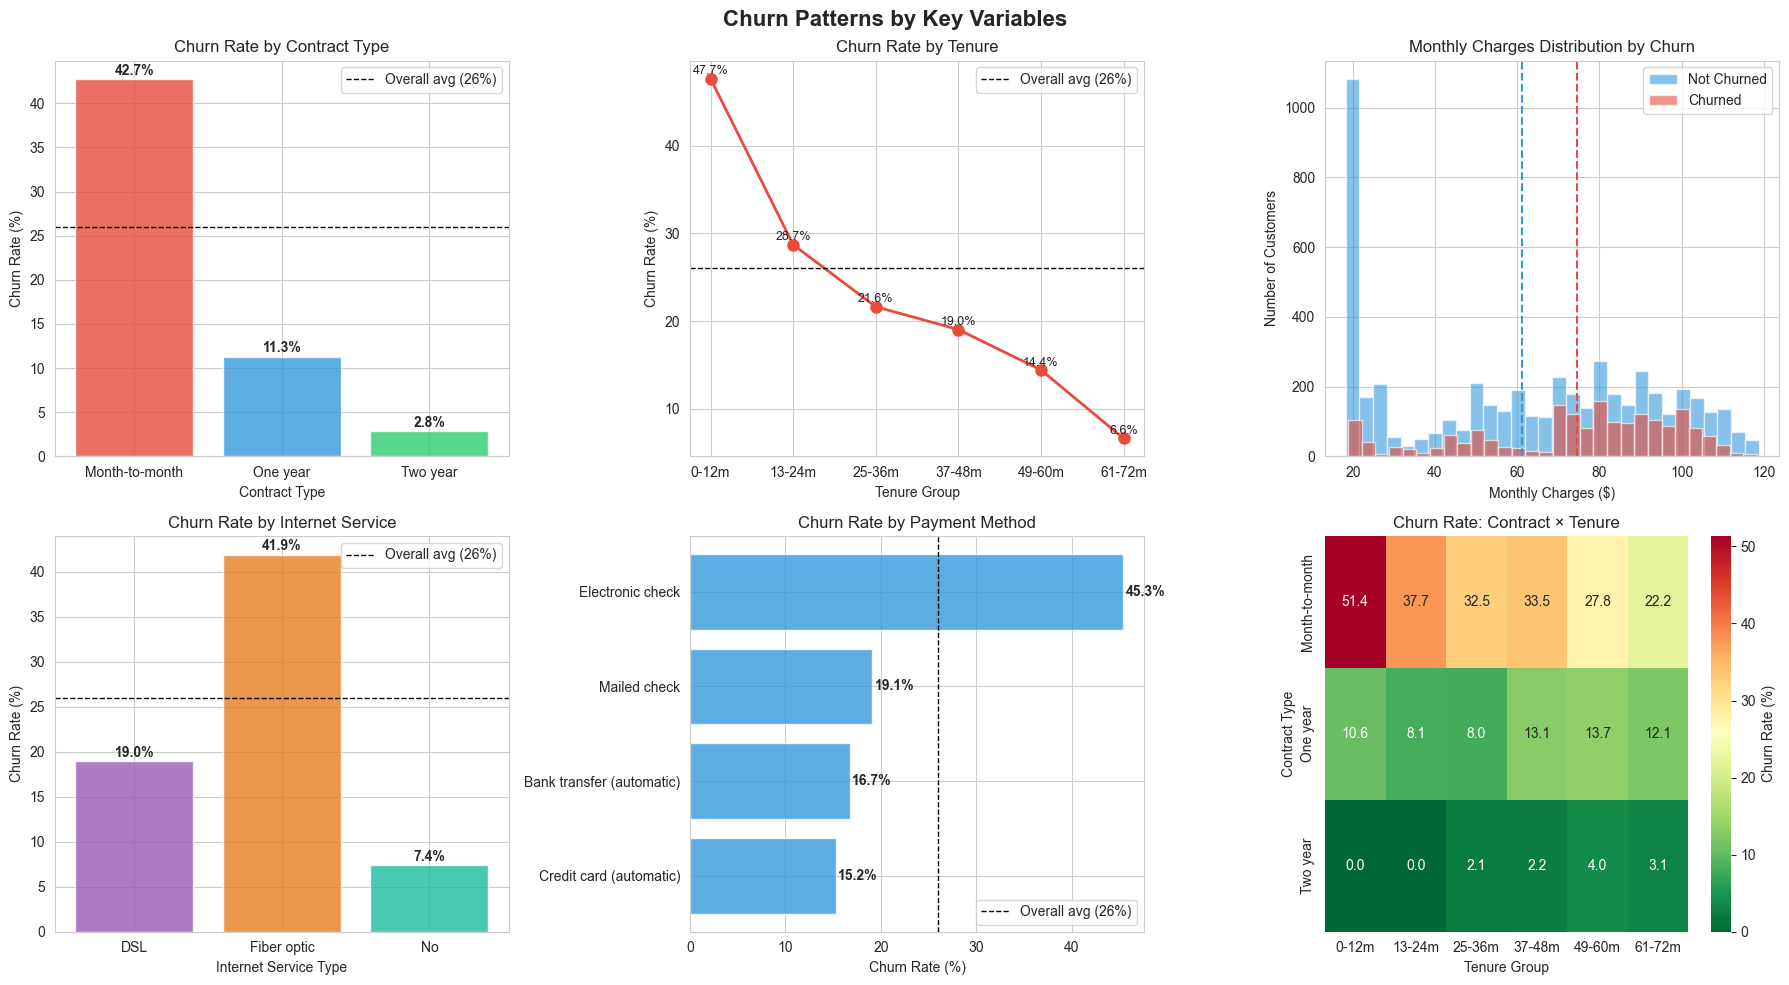


--- CHURN RATE SUMMARY ---

By Contract:
      Contract     Churn
Month-to-month 42.709677
      One year 11.269518
      Two year  2.831858

By Tenure Group:
tenure_group     Churn
       0-12m 47.678161
      13-24m 28.710938
      25-36m 21.634615
      37-48m 19.028871
      49-60m 14.423077
      61-72m  6.609808

By Internet Service:
InternetService     Churn
            DSL 18.959108
    Fiber optic 41.892765
             No  7.404980

By Payment Method:
            PaymentMethod     Churn
  Credit card (automatic) 15.243101
Bank transfer (automatic) 16.709845
             Mailed check 19.106700
         Electronic check 45.285412

Monthly Charges — Churned avg: $74.44 | Not churned avg: $61.27


In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Churn Patterns by Key Variables', fontsize=16, fontweight='bold')

# ── 1. Churn by Contract Type ──────────────────────────────────────────────
contract_churn = chn.groupby('Contract')['Churn'].mean().reset_index()
contract_churn['Churn'] = contract_churn['Churn'] * 100

axes[0,0].bar(contract_churn['Contract'], contract_churn['Churn'],
              color=['#e74c3c', '#3498db', '#2ecc71'], alpha=0.8)
axes[0,0].axhline(26, color='black', linestyle='--', linewidth=1, label='Overall avg (26%)')
axes[0,0].set_title('Churn Rate by Contract Type')
axes[0,0].set_ylabel('Churn Rate (%)')
axes[0,0].set_xlabel('Contract Type')
axes[0,0].legend()
for i, v in enumerate(contract_churn['Churn']):
    axes[0,0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# ── 2. Churn by Tenure ─────────────────────────────────────────────────────
chn['tenure_group'] = pd.cut(chn['tenure'],
                              bins=[0, 12, 24, 36, 48, 60, 72],
                              labels=['0-12m', '13-24m', '25-36m',
                                      '37-48m', '49-60m', '61-72m'])
tenure_churn = chn.groupby('tenure_group', observed=True)['Churn'].mean().reset_index()
tenure_churn['Churn'] = tenure_churn['Churn'] * 100

axes[0,1].plot(tenure_churn['tenure_group'].astype(str),
               tenure_churn['Churn'], marker='o', color='#e74c3c',
               linewidth=2, markersize=8)
axes[0,1].axhline(26, color='black', linestyle='--', linewidth=1, label='Overall avg (26%)')
axes[0,1].set_title('Churn Rate by Tenure')
axes[0,1].set_ylabel('Churn Rate (%)')
axes[0,1].set_xlabel('Tenure Group')
axes[0,1].legend()
for i, v in enumerate(tenure_churn['Churn']):
    axes[0,1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

# ── 3. Churn by Monthly Charges ────────────────────────────────────────────
churned     = chn[chn['Churn'] == 1]['MonthlyCharges']
not_churned = chn[chn['Churn'] == 0]['MonthlyCharges']

axes[0,2].hist(not_churned, bins=30, alpha=0.6, color='#3498db', label='Not Churned')
axes[0,2].hist(churned,     bins=30, alpha=0.6, color='#e74c3c', label='Churned')
axes[0,2].set_title('Monthly Charges Distribution by Churn')
axes[0,2].set_xlabel('Monthly Charges ($)')
axes[0,2].set_ylabel('Number of Customers')
axes[0,2].axvline(churned.mean(),     color='#e74c3c', linestyle='--', linewidth=1.5)
axes[0,2].axvline(not_churned.mean(), color='#3498db', linestyle='--', linewidth=1.5)
axes[0,2].legend()

# ── 4. Churn by Internet Service ───────────────────────────────────────────
internet_churn = chn.groupby('InternetService')['Churn'].mean().reset_index()
internet_churn['Churn'] = internet_churn['Churn'] * 100

axes[1,0].bar(internet_churn['InternetService'], internet_churn['Churn'],
              color=['#9b59b6', '#e67e22', '#1abc9c'], alpha=0.8)
axes[1,0].axhline(26, color='black', linestyle='--', linewidth=1, label='Overall avg (26%)')
axes[1,0].set_title('Churn Rate by Internet Service')
axes[1,0].set_ylabel('Churn Rate (%)')
axes[1,0].set_xlabel('Internet Service Type')
axes[1,0].legend()
for i, v in enumerate(internet_churn['Churn']):
    axes[1,0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# ── 5. Churn by Payment Method ─────────────────────────────────────────────
payment_churn = chn.groupby('PaymentMethod')['Churn'].mean().reset_index()
payment_churn['Churn'] = payment_churn['Churn'] * 100
payment_churn = payment_churn.sort_values('Churn', ascending=True)

axes[1,1].barh(payment_churn['PaymentMethod'], payment_churn['Churn'],
               color='#3498db', alpha=0.8)
axes[1,1].axvline(26, color='black', linestyle='--', linewidth=1, label='Overall avg (26%)')
axes[1,1].set_title('Churn Rate by Payment Method')
axes[1,1].set_xlabel('Churn Rate (%)')
axes[1,1].legend()
for i, v in enumerate(payment_churn['Churn']):
    axes[1,1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontweight='bold')

# ── 6. Churn by Contract × Tenure heatmap ─────────────────────────────────
pivot = chn.groupby(['Contract', 'tenure_group'],
                    observed=True)['Churn'].mean().unstack() * 100

sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=axes[1,2], cbar_kws={'label': 'Churn Rate (%)'})
axes[1,2].set_title('Churn Rate: Contract × Tenure')
axes[1,2].set_xlabel('Tenure Group')
axes[1,2].set_ylabel('Contract Type')

plt.tight_layout()
plt.savefig('Churn patterns by Key Varaibles.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Summary table ──────────────────────────────────────────────────────────
print("\n--- CHURN RATE SUMMARY ---")
print(f"\nBy Contract:\n{contract_churn.to_string(index=False)}")
print(f"\nBy Tenure Group:\n{tenure_churn.to_string(index=False)}")
print(f"\nBy Internet Service:\n{internet_churn.to_string(index=False)}")
print(f"\nBy Payment Method:\n{payment_churn.to_string(index=False)}")
print(f"\nMonthly Charges — Churned avg: ${churned.mean():.2f} | Not churned avg: ${not_churned.mean():.2f}")

CHI-SQUARE TESTS
        variable      chi2  p_value  cramers_v  significant effect_size
        Contract 1184.5966   0.0000     0.4101         True      Strong
  OnlineSecurity  849.9990   0.0000     0.3474         True      Strong
     TechSupport  828.1971   0.0000     0.3429         True      Strong
 InternetService  732.3096   0.0000     0.3225         True      Strong
   PaymentMethod  648.1423   0.0000     0.3034         True      Strong
    OnlineBackup  601.8128   0.0000     0.2923         True    Moderate
DeviceProtection  558.4194   0.0000     0.2816         True    Moderate
 StreamingMovies  375.6615   0.0000     0.2310         True    Moderate
     StreamingTV  374.2039   0.0000     0.2305         True    Moderate
PaperlessBilling  258.2776   0.0000     0.1915         True    Moderate
      Dependents  189.1292   0.0000     0.1639         True    Moderate
         Partner  158.7334   0.0000     0.1501         True    Moderate
   MultipleLines   11.3304   0.0035     0.0401 

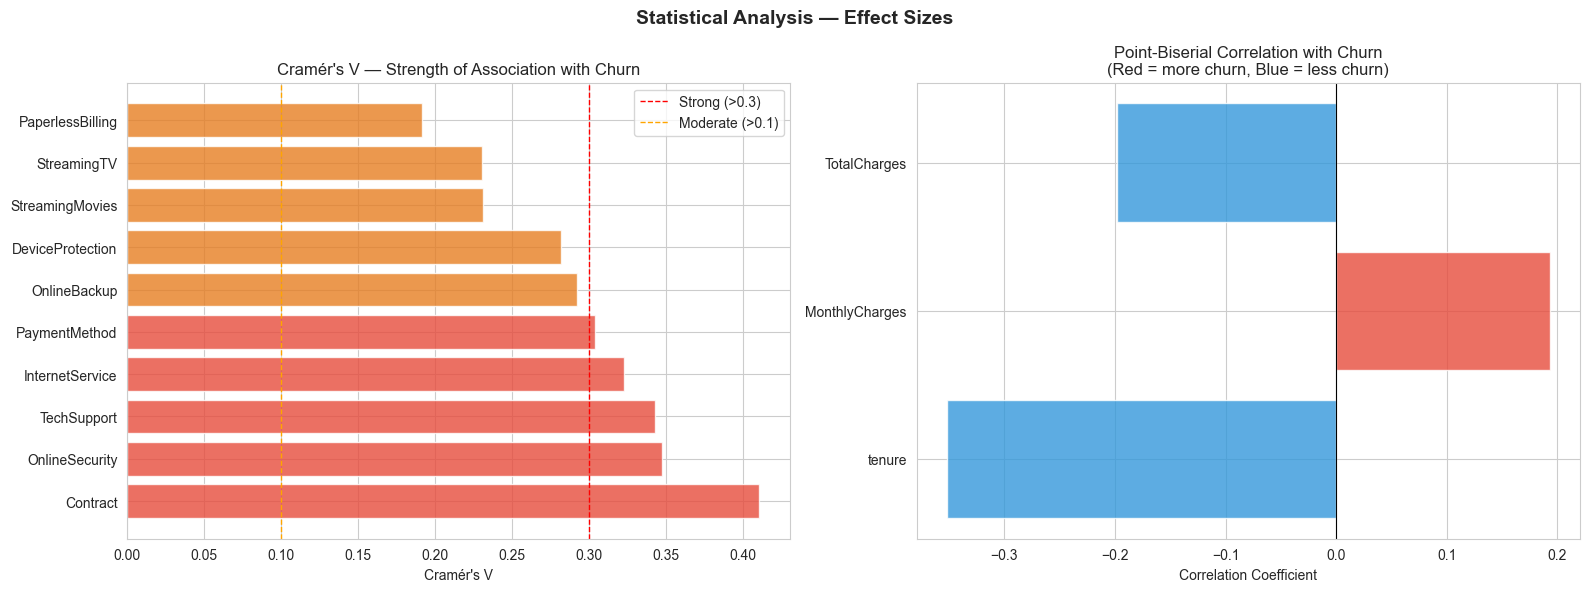

In [56]:
from scipy.stats import chi2_contingency, pointbiserialr
import numpy as np

# ── CHI-SQUARE TESTS (categorical variables vs Churn) ──────────────────────
print("=" * 60)
print("CHI-SQUARE TESTS")
print("=" * 60)

categorical_vars = ['Contract', 'InternetService', 'PaymentMethod',
                    'gender', 'Partner', 'Dependents', 'PhoneService',
                    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                    'DeviceProtection', 'TechSupport', 'StreamingTV',
                    'StreamingMovies', 'PaperlessBilling']

chi_results = []

for var in categorical_vars:
    contingency = pd.crosstab(chn[var], chn['Churn'])
    chi2, p, dof, _ = chi2_contingency(contingency)
    
    # Cramér's V — effect size (how STRONG is the relationship)
    n = contingency.sum().sum()
    min_dim = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim))
    
    chi_results.append({
        'variable':   var,
        'chi2':       round(chi2, 4),
        'p_value':    round(p, 4),
        'cramers_v':  round(cramers_v, 4),
        'significant': p < 0.05,
        'effect_size': 'Strong' if cramers_v > 0.3 else
                       'Moderate' if cramers_v > 0.1 else 'Weak'
    })

chi_df = pd.DataFrame(chi_results).sort_values('cramers_v', ascending=False)
print(chi_df.to_string(index=False))

# ── POINT-BISERIAL CORRELATION (continuous variables vs Churn) ─────────────
print("\n" + "=" * 60)
print("POINT-BISERIAL CORRELATION (Continuous vs Churn)")
print("=" * 60)

continuous_vars = ['tenure', 'MonthlyCharges', 'TotalCharges']

corr_results = []

for var in continuous_vars:
    clean = chn[['Churn', var]].dropna()
    corr, p = pointbiserialr(clean['Churn'], clean[var])
    
    corr_results.append({
        'variable':    var,
        'correlation': round(corr, 4),
        'p_value':     round(p, 6),
        'significant': p < 0.05,
        'direction':   'Higher = more churn' if corr > 0 else 'Higher = less churn',
        'strength':    'Strong' if abs(corr) > 0.3 else
                       'Moderate' if abs(corr) > 0.1 else 'Weak'
    })

corr_df = pd.DataFrame(corr_results)
print(corr_df.to_string(index=False))

# ── CONFIDENCE INTERVALS on key churn rates ────────────────────────────────
print("\n" + "=" * 60)
print("95% CONFIDENCE INTERVALS ON KEY CHURN RATES")
print("=" * 60)

def churn_ci(group_df):
    n    = len(group_df)
    p    = group_df['Churn'].mean()
    se   = np.sqrt(p * (1 - p) / n)
    return p, p - 1.96 * se, p + 1.96 * se, n

groups = {
    'Month-to-month': chn[chn['Contract'] == 'Month-to-month'],
    'One year':       chn[chn['Contract'] == 'One year'],
    'Two year':       chn[chn['Contract'] == 'Two year'],
    'Fiber optic':    chn[chn['InternetService'] == 'Fiber optic'],
    'DSL':            chn[chn['InternetService'] == 'DSL'],
    'Electronic check': chn[chn['PaymentMethod'] == 'Electronic check'],
    'Auto payment':   chn[chn['PaymentMethod'].isin(
                          ['Credit card (automatic)',
                           'Bank transfer (automatic)'])]
}

print(f"\n{'Group':<25} {'Churn Rate':>12} {'95% CI Lower':>14} {'95% CI Upper':>14} {'N':>6}")
print("-" * 75)
for name, group in groups.items():
    rate, lower, upper, n = churn_ci(group)
    print(f"{name:<25} {rate*100:>11.1f}% {lower*100:>13.1f}% {upper*100:>13.1f}% {n:>6}")

# ── VISUALISE: Effect sizes ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Statistical Analysis — Effect Sizes', fontsize=14, fontweight='bold')

# Cramér's V chart
chi_plot = chi_df.head(10)
colors = ['#e74c3c' if e == 'Strong' else
          '#e67e22' if e == 'Moderate' else '#3498db'
          for e in chi_plot['effect_size']]
axes[0].barh(chi_plot['variable'], chi_plot['cramers_v'], color=colors, alpha=0.8)
axes[0].axvline(0.3, color='red',    linestyle='--', linewidth=1, label='Strong (>0.3)')
axes[0].axvline(0.1, color='orange', linestyle='--', linewidth=1, label='Moderate (>0.1)')
axes[0].set_title("Cramér's V — Strength of Association with Churn")
axes[0].set_xlabel("Cramér's V")
axes[0].legend()

# Point-biserial chart
colors2 = ['#e74c3c' if c > 0 else '#3498db' for c in corr_df['correlation']]
axes[1].barh(corr_df['variable'], corr_df['correlation'], color=colors2, alpha=0.8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Point-Biserial Correlation with Churn\n(Red = more churn, Blue = less churn)')
axes[1].set_xlabel('Correlation Coefficient')

plt.tight_layout()
plt.savefig('Statistical Analysis.png', dpi=300, bbox_inches='tight')
plt.show()

Features used: 23
Feature list: ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']

Class distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64
Churn rate: 26.5%

Train size: 5634 | Test size: 1409

LOGISTIC REGRESSION
Test AUC:               0.8389
Cross-validated AUC:    0.8450 +/- 0.0123

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1409
 

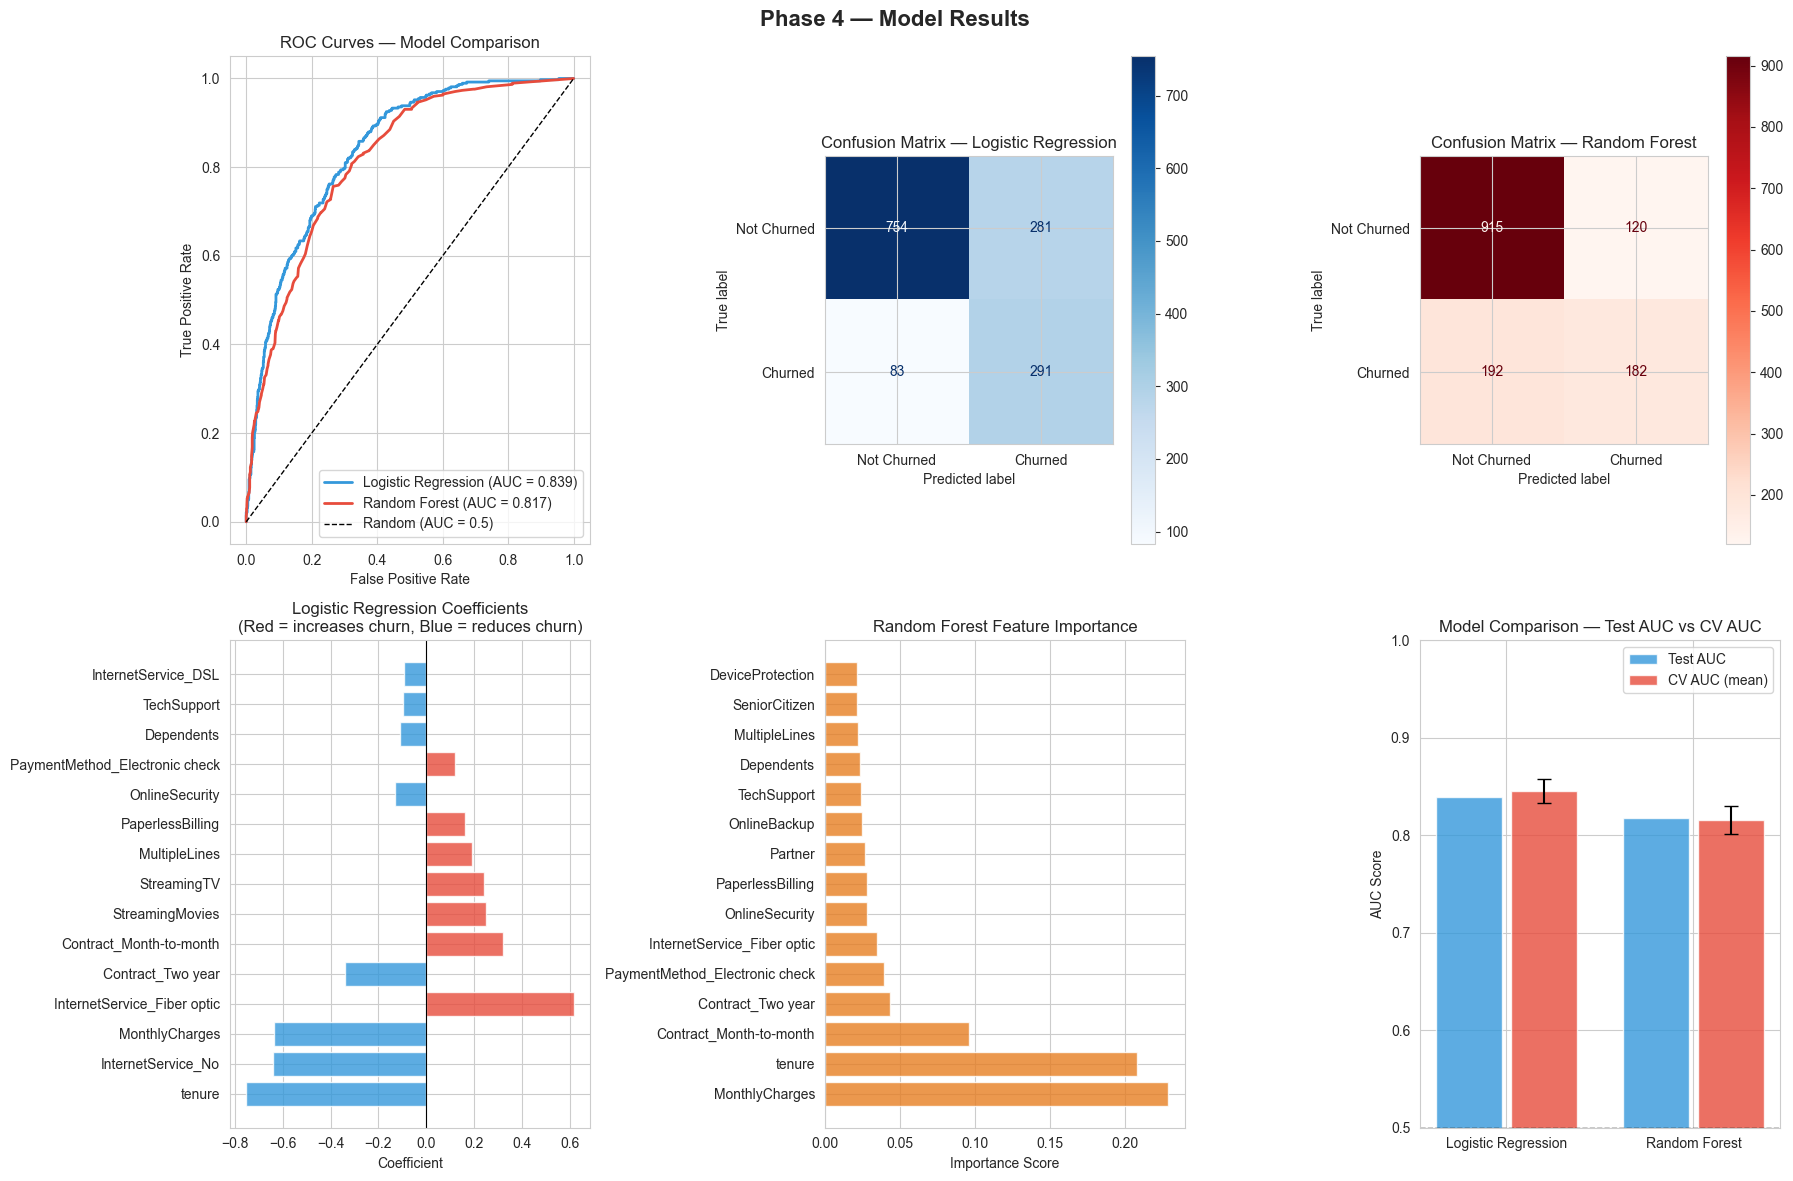

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, roc_auc_score,
                             roc_curve, confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# =============================================================================
# STEP 1 — FEATURE ENGINEERING
# Drop gender and PhoneService (statistically insignificant from Phase 3)
# =============================================================================

# Encode binary yes/no columns
binary_cols = ['Partner', 'Dependents', 'PaperlessBilling',
               'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
               'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']

for col in binary_cols:
    chn[col] = chn[col].map({'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0})

# One-hot encode multi-category columns
chn_model = pd.get_dummies(chn, columns=['Contract', 'InternetService', 'PaymentMethod'],
                            drop_first=False)

# Define features — exclude irrelevant ones from Phase 3
drop_cols = ['customerID', 'Churn', 'gender', 'PhoneService',
             'TotalCharges', 'tenure_group']  # TotalCharges is redundant with tenure
drop_cols = [c for c in drop_cols if c in chn_model.columns]

feature_cols = [c for c in chn_model.columns if c not in drop_cols]
X = chn_model[feature_cols].fillna(0)
y = chn_model['Churn'].astype(int)

print(f"Features used: {len(feature_cols)}")
print(f"Feature list: {feature_cols}")
print(f"\nClass distribution:\n{y.value_counts()}")
print(f"Churn rate: {y.mean()*100:.1f}%")

# =============================================================================
# STEP 2 — TRAIN / TEST SPLIT
# =============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {len(X_train)} | Test size: {len(X_test)}")

# Scale for logistic regression
scaler   = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# =============================================================================
# STEP 3 — LOGISTIC REGRESSION
# =============================================================================

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_scaled, y_train)

lr_preds = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]
lr_auc   = roc_auc_score(y_test, lr_proba)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_cv_auc = cross_val_score(lr, X_train_scaled, y_train,
                             cv=cv, scoring='roc_auc')

print("\n" + "="*60)
print("LOGISTIC REGRESSION")
print("="*60)
print(f"Test AUC:               {lr_auc:.4f}")
print(f"Cross-validated AUC:    {lr_cv_auc.mean():.4f} +/- {lr_cv_auc.std():.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, lr_preds)}")

# Coefficients — which features matter most
coef_df = pd.DataFrame({
    'feature':     feature_cols,
    'coefficient': lr.coef_[0],
    'abs_coef':    np.abs(lr.coef_[0])
}).sort_values('abs_coef', ascending=False)
print(f"\nTop 15 features by importance:\n{coef_df.head(15).to_string(index=False)}")

# =============================================================================
# STEP 4 — RANDOM FOREST
# =============================================================================

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_auc   = roc_auc_score(y_test, rf_proba)

rf_cv_auc = cross_val_score(rf, X_train, y_train,
                             cv=cv, scoring='roc_auc')

print("\n" + "="*60)
print("RANDOM FOREST")
print("="*60)
print(f"Test AUC:               {rf_auc:.4f}")
print(f"Cross-validated AUC:    {rf_cv_auc.mean():.4f} +/- {rf_cv_auc.std():.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, rf_preds)}")

# Feature importance
rf_importance = pd.DataFrame({
    'feature':    feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
print(f"\nTop 15 features by importance:\n{rf_importance.head(15).to_string(index=False)}")

# =============================================================================
# STEP 5 — VISUALISATIONS
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Phase 4 — Model Results', fontsize=16, fontweight='bold')

# ── ROC Curves ────────────────────────────────────────────────────────────
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)

axes[0,0].plot(fpr_lr, tpr_lr, color='#3498db',
               linewidth=2, label=f'Logistic Regression (AUC = {lr_auc:.3f})')
axes[0,0].plot(fpr_rf, tpr_rf, color='#e74c3c',
               linewidth=2, label=f'Random Forest (AUC = {rf_auc:.3f})')
axes[0,0].plot([0,1], [0,1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
axes[0,0].set_xlabel('False Positive Rate')
axes[0,0].set_ylabel('True Positive Rate')
axes[0,0].set_title('ROC Curves — Model Comparison')
axes[0,0].legend()

# ── Confusion Matrix — Logistic Regression ────────────────────────────────
ConfusionMatrixDisplay.from_predictions(y_test, lr_preds,
    display_labels=['Not Churned', 'Churned'],
    cmap='Blues', ax=axes[0,1])
axes[0,1].set_title('Confusion Matrix — Logistic Regression')

# ── Confusion Matrix — Random Forest ──────────────────────────────────────
ConfusionMatrixDisplay.from_predictions(y_test, rf_preds,
    display_labels=['Not Churned', 'Churned'],
    cmap='Reds', ax=axes[0,2])
axes[0,2].set_title('Confusion Matrix — Random Forest')

# ── Logistic Regression Coefficients ──────────────────────────────────────
top15_lr = coef_df.head(15)
colors_lr = ['#e74c3c' if c > 0 else '#3498db' for c in top15_lr['coefficient']]
axes[1,0].barh(top15_lr['feature'], top15_lr['coefficient'],
               color=colors_lr, alpha=0.8)
axes[1,0].axvline(0, color='black', linewidth=0.8)
axes[1,0].set_title('Logistic Regression Coefficients\n(Red = increases churn, Blue = reduces churn)')
axes[1,0].set_xlabel('Coefficient')

# ── Random Forest Feature Importance ──────────────────────────────────────
top15_rf = rf_importance.head(15)
axes[1,1].barh(top15_rf['feature'], top15_rf['importance'],
               color='#e67e22', alpha=0.8)
axes[1,1].set_title('Random Forest Feature Importance')
axes[1,1].set_xlabel('Importance Score')

# ── Model Comparison Summary ───────────────────────────────────────────────
models     = ['Logistic Regression', 'Random Forest']
auc_scores = [lr_auc, rf_auc]
cv_scores  = [lr_cv_auc.mean(), rf_cv_auc.mean()]
cv_stds    = [lr_cv_auc.std(), rf_cv_auc.std()]

x = np.arange(len(models))
axes[1,2].bar(x - 0.2, auc_scores, 0.35, label='Test AUC',
              color='#3498db', alpha=0.8)
axes[1,2].bar(x + 0.2, cv_scores,  0.35, label='CV AUC (mean)',
              color='#e74c3c', alpha=0.8)
axes[1,2].errorbar(x + 0.2, cv_scores, yerr=cv_stds,
                   fmt='none', color='black', capsize=5)
axes[1,2].set_xticks(x)
axes[1,2].set_xticklabels(models)
axes[1,2].set_ylim(0.5, 1.0)
axes[1,2].set_ylabel('AUC Score')
axes[1,2].set_title('Model Comparison — Test AUC vs CV AUC')
axes[1,2].legend()
axes[1,2].axhline(0.5, color='black', linestyle='--',
                  linewidth=1, label='Random baseline')

plt.tight_layout()
plt.savefig('Machine_Learning.png', dpi=300, bbox_inches='tight')
plt.show()

CUSTOMER RISK DISTRIBUTION
risk_segment
Low Risk         2989
Critical Risk    1764
Medium Risk      1183
High Risk        1107
Name: count, dtype: int64

Top 10 highest risk customers:
customerID  churn_probability  risk_segment  tenure       Contract  MonthlyCharges
9497-QCMMS           0.945815 Critical Risk       1 Month-to-month           93.55
9300-AGZNL           0.945325 Critical Risk       1 Month-to-month           94.00
5178-LMXOP           0.944997 Critical Risk       1 Month-to-month           95.10
7216-EWTRS           0.944041 Critical Risk       1 Month-to-month          100.80
7024-OHCCK           0.943887 Critical Risk       2 Month-to-month           93.85
4424-TKOPW           0.943887 Critical Risk       2 Month-to-month           93.85
2720-WGKHP           0.943718 Critical Risk       2 Month-to-month           94.00
5567-WSELE           0.942300 Critical Risk       3 Month-to-month           94.60
5150-ITWWB           0.941077 Critical Risk       3 Month-to-month 

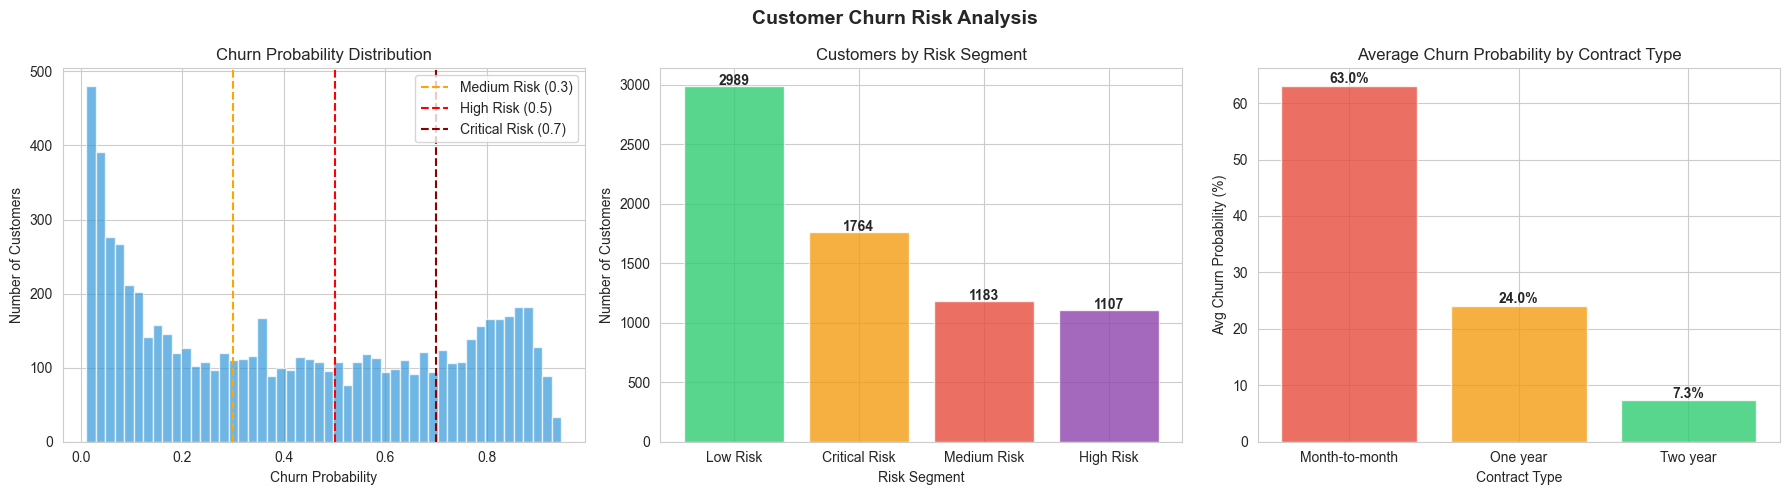


2871 high/critical risk customers exported to high_risk_customers.csv
These are the customers your retention team should contact first.


In [58]:
# =============================================================================
# PREDICTING CHURN PROBABILITY FOR CURRENT CUSTOMERS
# =============================================================================

# Step 1 — Generate churn probability for every customer in your dataset
# In reality this would be your current active customer base
# Here we use the full dataset to demonstrate

# Re-prepare features the same way as training
X_full = chn_model[feature_cols].fillna(0)
X_full_scaled = scaler.transform(X_full)  # use the SAME scaler from training

# Get churn probability from logistic regression (our better model)
churn_probabilities = lr.predict_proba(X_full_scaled)[:, 1]

# Step 2 — Build a customer risk table
risk_table = pd.DataFrame({
    'customerID':       chn['customerID'].values,
    'churn_probability': churn_probabilities,
    'actual_churn':      y.values,
    'tenure':            chn['tenure'].values,
    'Contract':          chn['Contract'].values,
    'MonthlyCharges':    chn['MonthlyCharges'].values,
    'InternetService':   chn['InternetService'].values,
    'PaymentMethod':     chn['PaymentMethod'].values
})

# Step 3 — Assign risk segments
risk_table['risk_segment'] = pd.cut(
    risk_table['churn_probability'],
    bins=[0, 0.3, 0.5, 0.7, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk', 'Critical Risk']
)

# Step 4 — Sort by highest risk first
risk_table = risk_table.sort_values('churn_probability', ascending=False)

print("="*60)
print("CUSTOMER RISK DISTRIBUTION")
print("="*60)
print(risk_table['risk_segment'].value_counts())
print(f"\nTop 10 highest risk customers:")
print(risk_table.head(10)[['customerID', 'churn_probability',
                            'risk_segment', 'tenure',
                            'Contract', 'MonthlyCharges']].to_string(index=False))

# Step 5 — Segment summary
print("\n" + "="*60)
print("RISK SEGMENT SUMMARY")
print("="*60)
segment_summary = risk_table.groupby('risk_segment', observed=True).agg(
    n_customers       = ('customerID', 'count'),
    avg_churn_prob    = ('churn_probability', 'mean'),
    avg_tenure        = ('tenure', 'mean'),
    avg_monthly       = ('MonthlyCharges', 'mean'),
    actual_churn_rate = ('actual_churn', 'mean')
).round(3)
print(segment_summary)

# =============================================================================
# VISUALISE THE RISK DISTRIBUTION
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Customer Churn Risk Analysis', fontsize=14, fontweight='bold')

# ── Churn probability distribution ────────────────────────────────────────
axes[0].hist(churn_probabilities, bins=50, color='#3498db', alpha=0.7, edgecolor='white')
axes[0].axvline(0.3, color='orange', linestyle='--', linewidth=1.5, label='Medium Risk (0.3)')
axes[0].axvline(0.5, color='red',    linestyle='--', linewidth=1.5, label='High Risk (0.5)')
axes[0].axvline(0.7, color='darkred',linestyle='--', linewidth=1.5, label='Critical Risk (0.7)')
axes[0].set_xlabel('Churn Probability')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Churn Probability Distribution')
axes[0].legend()

# ── Risk segment counts ────────────────────────────────────────────────────
segment_counts = risk_table['risk_segment'].value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']
axes[1].bar(segment_counts.index, segment_counts.values,
            color=colors, alpha=0.8)
axes[1].set_xlabel('Risk Segment')
axes[1].set_ylabel('Number of Customers')
axes[1].set_title('Customers by Risk Segment')
for i, v in enumerate(segment_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

# ── Churn probability by contract type ────────────────────────────────────
contract_risk = risk_table.groupby('Contract')['churn_probability'].mean().sort_values(ascending=False)
axes[2].bar(contract_risk.index, contract_risk.values * 100,
            color=['#e74c3c', '#f39c12', '#2ecc71'], alpha=0.8)
axes[2].set_xlabel('Contract Type')
axes[2].set_ylabel('Avg Churn Probability (%)')
axes[2].set_title('Average Churn Probability by Contract Type')
for i, v in enumerate(contract_risk.values * 100):
    axes[2].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('Customer Churn Risk analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# STEP 6 — EXPORT HIGH RISK CUSTOMERS FOR RETENTION TEAM
# This is the list your retention/CRM team would act on
# =============================================================================

high_risk = risk_table[risk_table['risk_segment'].isin(['High Risk', 'Critical Risk'])]
high_risk.to_csv('high_risk_customers.csv', index=False)

print(f"\n{len(high_risk)} high/critical risk customers exported to high_risk_customers.csv")
print("These are the customers your retention team should contact first.")

MONTHLY REVENUE AT RISK BY SEGMENT
               n_customers  total_monthly_revenue  revenue_at_risk  avg_monthly_charges  pct_revenue_at_risk
risk_segment                                                                                                
Low Risk              2989              167398.35         20968.04                56.00                 12.5
Medium Risk           1183               69075.65         27667.44                58.39                 40.1
High Risk             1107               76369.90         45899.71                68.99                 60.1
Critical Risk         1764              143272.70        117878.69                81.22                 82.3

Total monthly revenue:              $456,117
Total revenue at risk:              $212,414
Critical + High risk revenue:       $163,778
% of total revenue at risk:         46.6%


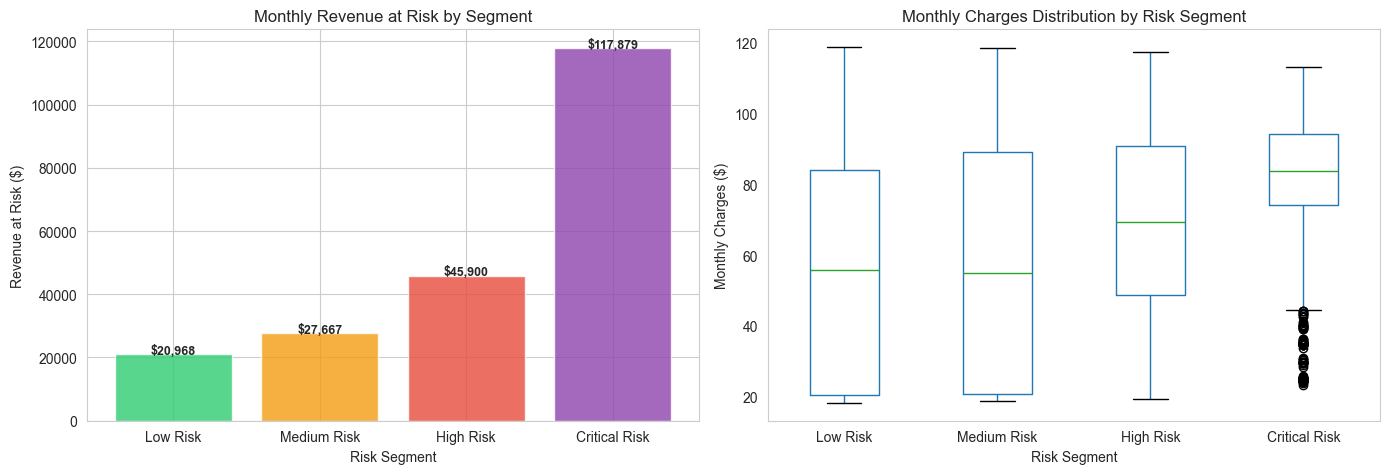

In [59]:
# Revenue at risk calculation
risk_table['monthly_revenue_at_risk'] = (
    risk_table['churn_probability'] * risk_table['MonthlyCharges']
)

revenue_summary = risk_table.groupby('risk_segment', observed=True).agg(
    n_customers          = ('customerID', 'count'),
    total_monthly_revenue= ('MonthlyCharges', 'sum'),
    revenue_at_risk      = ('monthly_revenue_at_risk', 'sum'),
    avg_monthly_charges  = ('MonthlyCharges', 'mean')
).round(2)

revenue_summary['pct_revenue_at_risk'] = (
    revenue_summary['revenue_at_risk'] /
    revenue_summary['total_monthly_revenue'] * 100
).round(1)

print("="*60)
print("MONTHLY REVENUE AT RISK BY SEGMENT")
print("="*60)
print(revenue_summary.to_string())

total_revenue     = risk_table['MonthlyCharges'].sum()
total_at_risk     = risk_table['monthly_revenue_at_risk'].sum()
critical_high     = risk_table[risk_table['risk_segment'].isin(
                    ['Critical Risk', 'High Risk'])]['monthly_revenue_at_risk'].sum()

print(f"\nTotal monthly revenue:              ${total_revenue:,.0f}")
print(f"Total revenue at risk:              ${total_at_risk:,.0f}")
print(f"Critical + High risk revenue:       ${critical_high:,.0f}")
print(f"% of total revenue at risk:         {total_at_risk/total_revenue*100:.1f}%")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Revenue at Risk Analysis', fontsize=14, fontweight='bold')

# Revenue at risk by segment
axes[0].bar(revenue_summary.index,
            revenue_summary['revenue_at_risk'],
            color=['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad'], alpha=0.8)
axes[0].set_title('Monthly Revenue at Risk by Segment')
axes[0].set_xlabel('Risk Segment')
axes[0].set_ylabel('Revenue at Risk ($)')
for i, v in enumerate(revenue_summary['revenue_at_risk']):
    axes[0].text(i, v + 100, f'${v:,.0f}', ha='center', fontweight='bold', fontsize=9)

# Charges distribution by segment
risk_table.boxplot(column='MonthlyCharges', by='risk_segment',
                   ax=axes[1], grid=False)
axes[1].set_title('Monthly Charges Distribution by Risk Segment')
axes[1].set_xlabel('Risk Segment')
axes[1].set_ylabel('Monthly Charges ($)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('Revenue_at_risk_Churn.png', dpi=300, bbox_inches='tight')
plt.show()

In [60]:
# Annualise the risk
monthly_at_risk   = 212414
annual_at_risk    = monthly_at_risk * 12

critical_monthly  = 117878
critical_annual   = critical_monthly * 12

print(f"Annual revenue at risk (all segments):  ${annual_at_risk:,.0f}")
print(f"Annual revenue at risk (critical only): ${critical_annual:,.0f}")

# What does it cost to retain vs lose them?
# Assume a 20% discount offer to retain critical risk customers
critical_customers     = 1764
avg_critical_charges   = 81.22
retention_discount     = 0.20
retention_success_rate = 0.50  # assume you save half of them

customers_saved     = critical_customers * retention_success_rate
revenue_saved       = customers_saved * avg_critical_charges * 12
cost_of_discounts   = customers_saved * (avg_critical_charges * retention_discount) * 12
net_retention_value = revenue_saved - cost_of_discounts

print(f"\n--- RETENTION INTERVENTION ESTIMATE (Critical Risk) ---")
print(f"Critical risk customers:        {critical_customers}")
print(f"Assumed save rate (50%):        {int(customers_saved)}")
print(f"Annual revenue saved:           ${revenue_saved:,.0f}")
print(f"Cost of 20% discount:           ${cost_of_discounts:,.0f}")
print(f"Net value of retention effort:  ${net_retention_value:,.0f}")

Annual revenue at risk (all segments):  $2,548,968
Annual revenue at risk (critical only): $1,414,536

--- RETENTION INTERVENTION ESTIMATE (Critical Risk) ---
Critical risk customers:        1764
Assumed save rate (50%):        882
Annual revenue saved:           $859,632
Cost of 20% discount:           $171,926
Net value of retention effort:  $687,706


FULL RETENTION BUSINESS CASE

Segment          Customers    Saved   Revenue Saved   Discount Cost    Net Value
--------------------------------------------------------------------------------
Critical Risk         1764      882 $      859,632 $      171,926 $    687,706
High Risk             1107      442 $      366,585 $       54,988 $    311,597
Medium Risk           1183      354 $      248,671 $       24,867 $    223,804
--------------------------------------------------------------------------------
TOTAL                          1679 $    1,474,889 $      251,781 $  1,223,108

Overall ROI:  486%
Customers retained: 1679 out of 4054 at-risk customers


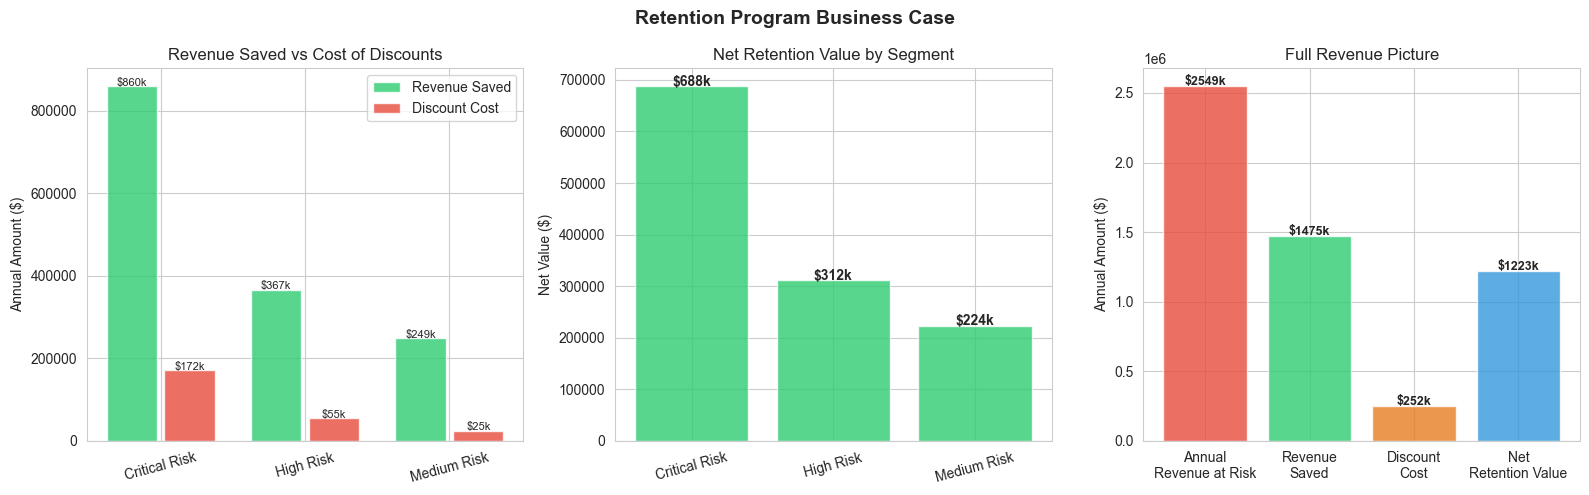


PRIORITY ACTION LIST FOR RETENTION TEAM

Total customers requiring action: 2871

Action breakdown:
recommended_action
URGENT: New month-to-month + high charges — offer contract switch + discount    1506
Contract switch offer — loyalty discount for annual commitment                  1249
Pricing review — consider plan downgrade or value-add offer                      103
General retention outreach                                                        13

Top 15 priority customers:
customerID  churn_probability  risk_segment  tenure       Contract  MonthlyCharges                                                           recommended_action
9497-QCMMS           0.945815 Critical Risk       1 Month-to-month           93.55 URGENT: New month-to-month + high charges — offer contract switch + discount
9300-AGZNL           0.945325 Critical Risk       1 Month-to-month           94.00 URGENT: New month-to-month + high charges — offer contract switch + discount
5178-LMXOP           0.944997 Cri

In [61]:
# Full retention ROI across all at-risk segments
print("="*60)
print("FULL RETENTION BUSINESS CASE")
print("="*60)

segments = {
    'Critical Risk': {'customers': 1764, 'avg_charges': 81.22,
                      'save_rate': 0.50, 'discount': 0.20},
    'High Risk':     {'customers': 1107, 'avg_charges': 68.99,
                      'save_rate': 0.40, 'discount': 0.15},
    'Medium Risk':   {'customers': 1183, 'avg_charges': 58.39,
                      'save_rate': 0.30, 'discount': 0.10},
}

total_saved       = 0
total_cost        = 0
total_net         = 0
total_customers_saved = 0

print(f"\n{'Segment':<15} {'Customers':>10} {'Saved':>8} "
      f"{'Revenue Saved':>15} {'Discount Cost':>15} {'Net Value':>12}")
print("-" * 80)

for segment, vals in segments.items():
    customers_saved  = vals['customers'] * vals['save_rate']
    revenue_saved    = customers_saved * vals['avg_charges'] * 12
    discount_cost    = customers_saved * (vals['avg_charges'] * vals['discount']) * 12
    net_value        = revenue_saved - discount_cost

    total_saved           += revenue_saved
    total_cost            += discount_cost
    total_net             += net_value
    total_customers_saved += customers_saved

    print(f"{segment:<15} {vals['customers']:>10} {int(customers_saved):>8} "
          f"${revenue_saved:>13,.0f} ${discount_cost:>13,.0f} ${net_value:>11,.0f}")

print("-" * 80)
print(f"{'TOTAL':<15} {'':>10} {int(total_customers_saved):>8} "
      f"${total_saved:>13,.0f} ${total_cost:>13,.0f} ${total_net:>11,.0f}")

print(f"\nOverall ROI:  {(total_net / total_cost) * 100:.0f}%")
print(f"Customers retained: {int(total_customers_saved)} "
      f"out of {1764+1107+1183} at-risk customers")

# ── Visualise the business case ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Retention Program Business Case', fontsize=14, fontweight='bold')

seg_names     = list(segments.keys())
rev_saved     = []
disc_cost     = []
net_vals      = []

for seg, vals in segments.items():
    cs = vals['customers'] * vals['save_rate']
    rs = cs * vals['avg_charges'] * 12
    dc = cs * (vals['avg_charges'] * vals['discount']) * 12
    rev_saved.append(rs)
    disc_cost.append(dc)
    net_vals.append(rs - dc)

x = np.arange(len(seg_names))

# Revenue saved vs cost
axes[0].bar(x - 0.2, rev_saved, 0.35, label='Revenue Saved',
            color='#2ecc71', alpha=0.8)
axes[0].bar(x + 0.2, disc_cost, 0.35, label='Discount Cost',
            color='#e74c3c', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(seg_names, rotation=15)
axes[0].set_ylabel('Annual Amount ($)')
axes[0].set_title('Revenue Saved vs Cost of Discounts')
axes[0].legend()
for i in range(len(seg_names)):
    axes[0].text(i - 0.2, rev_saved[i] + 1000,
                 f'${rev_saved[i]/1000:.0f}k', ha='center', fontsize=8)
    axes[0].text(i + 0.2, disc_cost[i] + 1000,
                 f'${disc_cost[i]/1000:.0f}k', ha='center', fontsize=8)

# Net value by segment
colors_net = ['#2ecc71' if v > 0 else '#e74c3c' for v in net_vals]
axes[1].bar(seg_names, net_vals, color=colors_net, alpha=0.8)
axes[1].set_ylabel('Net Value ($)')
axes[1].set_title('Net Retention Value by Segment')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(net_vals):
    axes[1].text(i, v + 1000, f'${v/1000:.0f}k', ha='center', fontweight='bold')

# Waterfall: total picture
categories  = ['Annual\nRevenue at Risk', 'Revenue\nSaved', 'Discount\nCost', 'Net\nRetention Value']
values      = [2548968, total_saved, -total_cost, total_net]
bar_colors  = ['#e74c3c', '#2ecc71', '#e67e22', '#3498db']
axes[2].bar(categories, [abs(v) for v in values], color=bar_colors, alpha=0.8)
axes[2].set_ylabel('Annual Amount ($)')
axes[2].set_title('Full Revenue Picture')
for i, v in enumerate(values):
    axes[2].text(i, abs(v) + 5000, f'${abs(v)/1000:.0f}k',
                 ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('Retention_Program_Business_Cas.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Priority action list ───────────────────────────────────────────────────
print("\n" + "="*60)
print("PRIORITY ACTION LIST FOR RETENTION TEAM")
print("="*60)

priority_list = risk_table[
    risk_table['risk_segment'].isin(['Critical Risk', 'High Risk'])
].copy()

# Tag the primary reason for risk on each customer
conditions = [
    (priority_list['Contract'] == 'Month-to-month') &
    (priority_list['tenure'] <= 12),
    (priority_list['Contract'] == 'Month-to-month') &
    (priority_list['tenure'] > 12),
    (priority_list['MonthlyCharges'] > 75),
]
actions = [
    'URGENT: New month-to-month + high charges — offer contract switch + discount',
    'Contract switch offer — loyalty discount for annual commitment',
    'Pricing review — consider plan downgrade or value-add offer',
]
priority_list['recommended_action'] = np.select(conditions, actions,
                                       default='General retention outreach')

priority_list = priority_list.sort_values('churn_probability', ascending=False)

print(f"\nTotal customers requiring action: {len(priority_list)}")
print(f"\nAction breakdown:")
print(priority_list['recommended_action'].value_counts().to_string())
print(f"\nTop 15 priority customers:")
print(priority_list[['customerID', 'churn_probability', 'risk_segment',
                      'tenure', 'Contract', 'MonthlyCharges',
                      'recommended_action']].head(15).to_string(index=False))

# Export final action list
priority_list.to_csv('retention_action_list.csv', index=False)
print(f"\nFull action list exported to retention_action_list.csv")